# 37_ridge_mcd_dashboard_JSC

- 목적: 최종 운영 모델인 Ridge `[first_difference]` 주의 → Ridge AND MCD `[diff_amp]` 경보를 한눈에 확인하는 정적 단일 HTML 대시보드를 만든다.
- 입력: `results/23_model_ensemble_ridge_mcd_JSC/`의 저장 점수·성능·처리시간, `results/34_realtime_input_validation_JSC/stream_timing.csv`, `data/processed/segments.csv`
- 출력: `figures/37_ridge_mcd_dashboard_JSC/`의 HTML·PNG, `results/37_ridge_mcd_dashboard_JSC/`의 요약·재생 세그먼트·계약 점검 CSV
- 담당: JSC
- 심사 대응: 4번(현장 활용), 5번(2단계 경보 시각화), 6번(서버 없는 재현 가능한 산출물)

> 이 화면은 실제 설비 통신이 아니라 저장 데이터의 **정적 스트림 재생**이다. Grafana·Tableau·시계열 DB·외부 계정을 사용하지 않는다.

In [1]:
import sys, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib; matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import Image, display
warnings.filterwarnings("ignore")
ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT / "src"))
import paths
import dashboard_jsc as D
NB = "37_ridge_mcd_dashboard_JSC"
FIG, RES = paths.nb_dirs(NB)
SEED = 0
np.random.seed(SEED)
pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 20)
print(NB, FIG.relative_to(ROOT), RES.relative_to(ROOT))

37_ridge_mcd_dashboard_JSC figures\37_ridge_mcd_dashboard_JSC results\37_ridge_mcd_dashboard_JSC


## 1. 표시·판정 계약

| 항목 | 계약 |
|---|---|
| 주의 | 같은 fold의 학습 정상 q99로 나눈 Ridge 점수 `z_ridge_diff > 1` |
| 경보 | 같은 1초 창에서 Ridge와 MCD가 모두 초과, `min(z_ridge_diff, z_mcd_diff_amp) > 1` |
| 정상 화면 | time-block 평가 블록 1~4의 정상 417세그먼트, seed 0 |
| 이상 화면 | 같은 이벤트의 중복 표시를 피하려고 forward fold 4·seed 0 한 벌 |
| 상태 | 0=고부하, 1=저부하 |
| 시간 | `segments.csv`의 burst 시작 시각 + 창의 `t_start`; 화면에는 각 재생 열의 상대 시간 표시 |

화면 선택은 설명을 위한 것이며 성능 카드에는 특정 fold가 아니라 23번의 전체 time-block 평균을 사용한다.

In [2]:
bundle = D.build_dashboard(FIG, RES)
metrics = bundle["metrics"]
segments = bundle["segments"]
checks = bundle["checks"]
display(metrics)
display(checks)

,metric,value,unit,source,note
0,주의 세그먼트 FPR,0.016959,ratio,23 summary.csv,time-block 평균
1,경보 세그먼트 FPR,0.002451,ratio,23 summary.csv,time-block 평균
2,주의 이상 탐지,17.000000,segments,23 summary.csv,판정 가능 17세그먼트
3,경보 이상 탐지,17.000000,segments,23 summary.csv,판정 가능 17세그먼트
4,경보 지연 중앙값,0.900000,s,23 summary.csv,burst 내부 최초 판정
5,경보 고부하 FPR,0.004902,ratio,23 summary.csv,time-block
6,경보 저부하 FPR,0.000000,ratio,23 summary.csv,time-block
7,Ridge 샘플 처리 최댓값,0.387533,ms/sample,34 stream_timing.csv,"형식 통일 후 입력 변환·예측, I/O 제외"
8,MCD 포함 점수 계산 최댓값,0.099699,ms/window,23 timing.csv,"피처 준비 후 점수 계산, I/O 제외"


,check,passed,detail
0,AND 점수 관계,True,"z_alarm = min(z_ridge, z_mcd)"
1,정상 평가 세그먼트,True,417개
2,대표 이상 세그먼트,True,17개
3,이상 경보 포함,True,경보 17/17
4,정상 저부하 경보 없음,True,저부하 경보 0개
5,저장 성능표 탐지 일치,True,time-block 17/17


## 2. 재생 데이터 요약

정상 스트림에서 Ridge 주의는 7세그먼트, 그중 Ridge와 MCD가 같은 창에서 함께 초과한 최종 경보는 `normal_178` 한 건이다. `normal_331`은 두 모델의 세그먼트 최대가 모두 1을 넘지만 초과 창이 달라 주의로 남는다. 이는 AND를 세그먼트 최대끼리 결합하지 않고 **창 단위로 먼저 결합**해야 하는 이유다.

이상 화면의 17세그먼트는 독립 고장 17건이 아니라 하나의 실제 이상 이벤트 중 1초 판정이 가능한 burst들이다.

In [3]:
stage_counts = segments.groupby(["view", "state_name", "stage"], dropna=False).size().rename("segments").reset_index()
flagged_normal = segments[(segments.view == "normal") & (segments.stage != "normal")][
    ["seg_uid", "fold", "state_name", "ridge_max", "mcd_max", "alarm_max", "stage"]
].round(3)
display(stage_counts)
display(flagged_normal)

,view,state_name,stage,segments
0,normal,고부하,alarm,1
1,normal,고부하,caution,6
2,normal,고부하,normal,164
3,normal,저부하,normal,246
4,outlier,미분류,alarm,17


,seg_uid,fold,state_name,ridge_max,mcd_max,alarm_max,stage
24,normal_149,1,고부하,1.112,0.389,0.389,caution
44,normal_175,1,고부하,1.156,0.433,0.433,caution
47,normal_178,1,고부하,1.471,1.875,1.471,alarm
67,normal_201,1,고부하,1.023,0.415,0.415,caution
177,normal_331,2,고부하,1.136,1.195,0.792,caution
247,normal_413,3,고부하,1.706,0.899,0.899,caution
390,normal_569,4,고부하,1.456,0.245,0.245,caution


## 3. 정적 대시보드 산출물

HTML 안에 그림·스타일·탭 전환 스크립트를 모두 포함한다. 파일을 브라우저로 직접 열 수 있으며 인터넷 연결·서버·계정·상용 라이선스가 필요 없다. 탭 전환은 화면 표시만 바꾸며 판정 수치를 다시 계산하지 않는다.

dashboard figures\37_ridge_mcd_dashboard_JSC\dashboard.html 636.3 KB


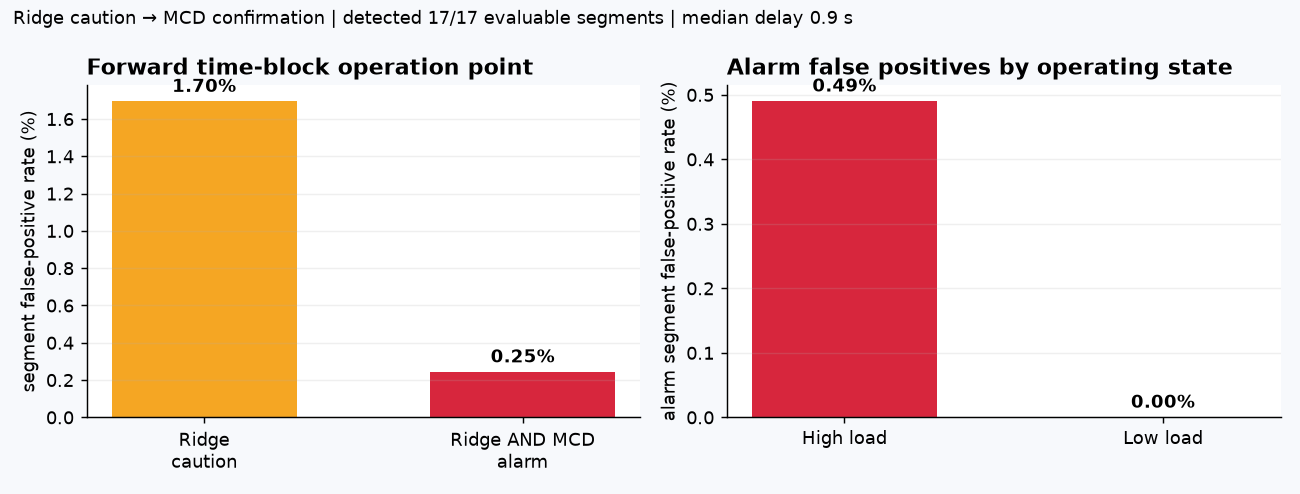

브라우저로 열기: figures\37_ridge_mcd_dashboard_JSC\dashboard.html


In [4]:
html_path = bundle["html"]
assert html_path.exists() and html_path.stat().st_size > 100_000
assert all((FIG / name).exists() for name in ["normal_replay.png", "outlier_replay.png", "dashboard_preview.png"])
assert all((RES / name).exists() for name in ["dashboard_summary.csv", "replay_segments.csv", "contract_checks.csv"])
print("dashboard", html_path.relative_to(ROOT), f"{html_path.stat().st_size / 1024:.1f} KB")
display(Image(FIG / "dashboard_preview.png"))
print("브라우저로 열기:", html_path.relative_to(ROOT))

## 4. 해석과 한계

- **발견:** time-block에서 Ridge 주의의 세그먼트 FPR 1.70%가 MCD 동시 확인 후 0.25%로 낮아지고, 판정 가능한 실제 이상 17/17은 유지된다.
- **시사점:** 대시보드는 단일 점수를 고장 확률처럼 보여주지 않고 Ridge·MCD 점수, 임계선, 주의·경보 포함 관계를 함께 보여준다.
- **활용 아이디어 [가정]:** 현장에서는 같은 결과 컬럼을 시계열 저장소와 모니터링 도구에 연결할 수 있다. 이번 제출에서는 그 외부 시스템을 구축했다고 주장하지 않는다.
- **한계:** 실제 설비 통신·DB·알림 전송은 검증하지 않았다. 이상 데이터는 한 이벤트이고, 고장 부품과 남은 수명은 판단할 수 없다.

상세 해석은 `reports/37_ridge_mcd_dashboard_JSC.md`에 정리한다.